In [3]:
import nltk

In [4]:
# Do not run
nltk.download('gutenberg')
nltk.download('genesis')
nltk.download('inaugural')
nltk.download('nps_chat')
nltk.download('webtext')
nltk.download('treebank')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package gutenberg to
[nltk_data]     /Users/nishantsnaik/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package genesis to
[nltk_data]     /Users/nishantsnaik/nltk_data...
[nltk_data]   Unzipping corpora/genesis.zip.
[nltk_data] Downloading package inaugural to
[nltk_data]     /Users/nishantsnaik/nltk_data...
[nltk_data]   Unzipping corpora/inaugural.zip.
[nltk_data] Downloading package nps_chat to
[nltk_data]     /Users/nishantsnaik/nltk_data...
[nltk_data]   Unzipping corpora/nps_chat.zip.
[nltk_data] Downloading package webtext to
[nltk_data]     /Users/nishantsnaik/nltk_data...
[nltk_data]   Unzipping corpora/webtext.zip.
[nltk_data] Downloading package treebank to
[nltk_data]     /Users/nishantsnaik/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nishantsnaik/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downl

True

In [5]:
# Do not run
from nltk.book import *
#Some open texts available in NLTK

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


In [6]:
#Let's work with 'Moby Dick by Herman Melville 1851'
text1

<Text: Moby Dick by Herman Melville 1851>

In [7]:
tokens = text1.tokens # Words in the book
tokens

['[',
 'Moby',
 'Dick',
 'by',
 'Herman',
 'Melville',
 '1851',
 ']',
 'ETYMOLOGY',
 '.',
 '(',
 'Supplied',
 'by',
 'a',
 'Late',
 'Consumptive',
 'Usher',
 'to',
 'a',
 'Grammar',
 'School',
 ')',
 'The',
 'pale',
 'Usher',
 '--',
 'threadbare',
 'in',
 'coat',
 ',',
 'heart',
 ',',
 'body',
 ',',
 'and',
 'brain',
 ';',
 'I',
 'see',
 'him',
 'now',
 '.',
 'He',
 'was',
 'ever',
 'dusting',
 'his',
 'old',
 'lexicons',
 'and',
 'grammars',
 ',',
 'with',
 'a',
 'queer',
 'handkerchief',
 ',',
 'mockingly',
 'embellished',
 'with',
 'all',
 'the',
 'gay',
 'flags',
 'of',
 'all',
 'the',
 'known',
 'nations',
 'of',
 'the',
 'world',
 '.',
 'He',
 'loved',
 'to',
 'dust',
 'his',
 'old',
 'grammars',
 ';',
 'it',
 'somehow',
 'mildly',
 'reminded',
 'him',
 'of',
 'his',
 'mortality',
 '.',
 '"',
 'While',
 'you',
 'take',
 'in',
 'hand',
 'to',
 'school',
 'others',
 ',',
 'and',
 'to',
 'teach',
 'them',
 'by',
 'what',
 'name',
 'a',
 'whale',
 '-',
 'fish',
 'is',
 'to',
 'be',
 

In [9]:
len(tokens) # No. of words in the book

260819

## NGrams

In [11]:
# You can create features from pairs of words, triplets, and so on..
# ngrams is a useful function which can give you 'n' consecutive words
from nltk.util import ngrams
bigrams = ngrams(tokens,2)

In [16]:
bigrams

<generator object ngrams at 0x1173f9250>

In [19]:
#Let's try to get some word pairs that are 'Adjectives' followed by a 'Noun'
#('Adjective', 'Noun')

from nltk import pos_tag
# The pos_tag for adjectives starts with 'J'. For Nouns, it starts with 'N'

cnt = 0
for j in bigrams:
    first_token = j[0]
    first_tag = pos_tag([first_token])
    second_token = j[1]
    second_tag = pos_tag([second_token])
    # pos_tag(['Librarian']) --> [('Librarian', 'JJ')]
    # N: Noun. J: Adjective

    # first_tag[0] --> ('Librarian', 'JJ')
    # # first_tag[0][1] --> 'JJ'
    if(first_tag[0][1][0] == 'J') and (second_tag[0][1][0] == 'N'):
        # print(j)
        cnt += 1
        print(first_token + " " + second_token)
    if cnt == 10:
      break


Consumptive Usher
old lexicons
old grammars
true ."
Librarian ).
poor devil
veritable gospel
many nations
poor devil
full eyes


In [20]:
#Let's try to extract some common phrases of length 3
#('Determiner', 'Adjective', 'Noun')
trigrams = ngrams(tokens, 3)

cnt = 0
for j in trigrams:
    if(pos_tag([j[0]])[0][1][0] == 'D') and (pos_tag([j[1]])[0][1][0] == 'J') and ((pos_tag([j[2]])[0][1][0] == 'N')):
        print(j)
        cnt += 1
    if cnt == 100:
      break

('a', 'poor', 'devil')
('a', 'great', 'fish')
('The', 'Indian', 'Sea')
('the', 'biggest', 'fishes')
('The', 'best', 'whales')
('the', 'other', 'things')
('the', 'noble', 'prophet')
('The', 'great', 'Leviathan')
('an', 'incredible', 'quantity')
('an', 'artificial', 'man')
('The', 'huge', 'Leviathan')
('a', 'great', 'deal')
('those', 'southern', 'seas')
('an', 'insupportable', 'smell')
('the', 'important', 'charge')
('the', 'largest', 'animal')
('a', 'dead', 'whale')
('The', 'larger', 'whales')
('some', 'other', 'articles')
('the', 'same', 'nature')
('THE', 'FRENCH', 'MINISTER')
('a', 'great', 'whale')
('the', 'main', 'pipe')
('a', 'mammiferous', 'animal')
('the', 'free', 'element')
('a', 'high', 'hill')
('a', 'green', 'pasture')
('a', 'Gothic', 'Arch')
('A', 'LARGE', 'SPERM')
('these', 'fresh', 'attacks')
('a', 'commercial', 'point')
('the', 'most', 'abundant')
('the', 'most', 'convenient')
('a', 'formidable', 'weapon')
('the', 'furious', 'monster')
('the', 'least', 'damn')
('the', 'wid

In [21]:
# Out of all the bigrams, let's try to find the most frequent ones
from nltk.collocations import BigramCollocationFinder
from nltk.collocations import *
finder = BigramCollocationFinder.from_words(tokens)

In [25]:
for k,v in list(finder.ngram_fd.items())[:5]:
    print(k,v)

('[', 'Moby') 1
('Moby', 'Dick') 83
('Dick', 'by') 1
('by', 'Herman') 1
('Herman', 'Melville') 1


In [26]:
finder.apply_freq_filter(4) # Apply a filter with frequency 4
for k,v in list(finder.ngram_fd.items())[:10]:
  print(k,v)

('Moby', 'Dick') 83
('.', '(') 56
('by', 'a') 80
('to', 'a') 111
('coat', ',') 8
('heart', ',') 17
('body', ',') 19
(',', 'and') 2607
('brain', ';') 6
(';', 'I') 96


### Using PMI (Pointwise Mutual Information) for filtering

There are many probability measures such as likelihood ratio or PMI that compute probability of a word relative to other words in a corpus.

PMI measures the association of two words by calculating

$\text{log} \frac{p(x, y)}{p(x) \space p(y)} = \text{log} \frac{p(x|y) p(y)}{p(x) \space p(y)} = \text{log} \frac{p(x|y)}{p(x)}$

Let's say you have 100 words in the corpus, and if frequency of a certain word x is 10 and it only occurs with another word y only once.

p(x|y) = log $\frac{p(x, y)} {p(x)} = \text{log} \frac{\frac{1}{100}}{\frac{1}{10}} = \text{log} \frac{0.01}{0.1} = \text{log } 0.1$ = -1

PMI value of zero indicates no association.
A positive PMI indicates that two words are more likely to cooccur
A negative PMI indicates that two words are less likely to cooccur

In [32]:
bigram_measures = nltk.collocations.BigramAssocMeasures()
finder.nbest(bigram_measures.pmi, 5) #5 most common bigrams with Pointwise_Mutual_Inormation (PMI)

[('Deacon', 'Deuteronomy'),
 ('Aunt', 'Charity'),
 ('Frederick', 'Cuvier'),
 ('Samuel', 'Enderby'),
 ('Father', 'Mapple')]

In [33]:
# Similarly, you can find the most useful Trigrams
from nltk.collocations import TrigramCollocationFinder
from nltk.collocations import *
trigram_measures = nltk.collocations.TrigramAssocMeasures()

finder = TrigramCollocationFinder.from_words(tokens)
finder.apply_freq_filter(3)
finder.nbest(trigram_measures.pmi, 5)

[('OLD', 'MANX', 'SAILOR'),
 ('First', 'Night', 'Watch'),
 ('SACRED', 'TO', 'THE'),
 ('TO', 'THE', 'MEMORY'),
 ('Eight', 'bells', 'there')]

In [34]:
# For Quadgrams
from nltk.collocations import QuadgramCollocationFinder
from nltk.collocations import *
quadgram_measures = nltk.collocations.QuadgramAssocMeasures()

finder = QuadgramCollocationFinder.from_words(tokens)
finder.apply_freq_filter(4)
finder.nbest(quadgram_measures.pmi, 5)

[('(', 'FOLIO', '),', 'CHAPTER'),
 ('(', 'OCTAVO', '),', 'CHAPTER'),
 ('Cape', 'of', 'Good', 'Hope'),
 ('!', 'caw', '!', 'caw'),
 ('caw', '!', 'caw', '!')]

Frequency Distribution

In [36]:
from nltk import FreqDist
FreqDist(text1.tokens)

FreqDist({',': 18713, 'the': 13721, '.': 6862, 'of': 6536, 'and': 6024, 'a': 4569, 'to': 4542, ';': 4072, 'in': 3916, 'that': 2982, ...})

In [37]:
FreqDist(text1.tokens).most_common(10)

[(',', 18713),
 ('the', 13721),
 ('.', 6862),
 ('of', 6536),
 ('and', 6024),
 ('a', 4569),
 ('to', 4542),
 (';', 4072),
 ('in', 3916),
 ('that', 2982)]

<Axes: xlabel='Samples', ylabel='Counts'>

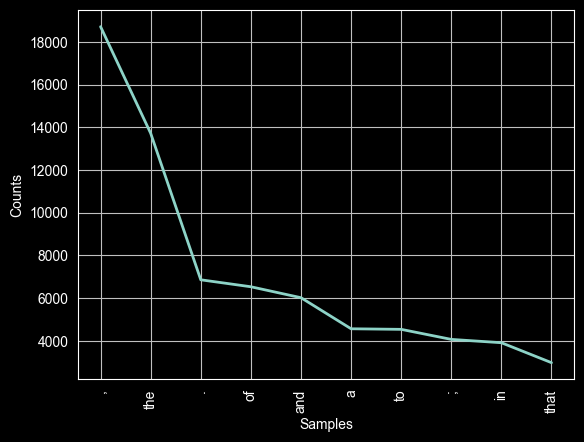

In [38]:
# Histogram of the most frequent words
FreqDist.plot(FreqDist(text1.tokens), 10) # 10 is the number of samples on the x-axis + 1

<Axes: xlabel='Samples', ylabel='Counts'>

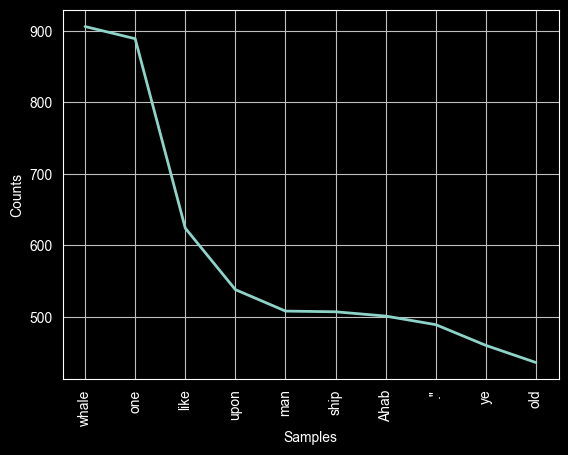

In [40]:
# Before generatng it, remove the stopwords
from nltk.corpus import stopwords
sw_list = stopwords.words('english')

sw_list.extend([',', '-','/','.',';','"','-','!',"'",'?','|','_','--',':','#','$','''"''','..',])
tokens_after_sw = []
for each in text1.tokens:
    if each.lower() not in sw_list:
        tokens_after_sw.append(each)

FreqDist(tokens_after_sw).plot(10)

In [41]:
#Let's make a wordcloud
from urllib import request
url = "http://www.gutenberg.org/files/2554/2554-0.txt"
response = request.urlopen(url)
raw = response.read().decode('utf8')
print(type(raw)) #DataType
print(len(raw)) #No. of words in the file
print(raw[:75]) #Printing the first few words

<class 'str'>
1135213
*** START OF THE PROJECT GUTENBERG EBOOK 2554 ***




CRIME AND PUNISHMENT



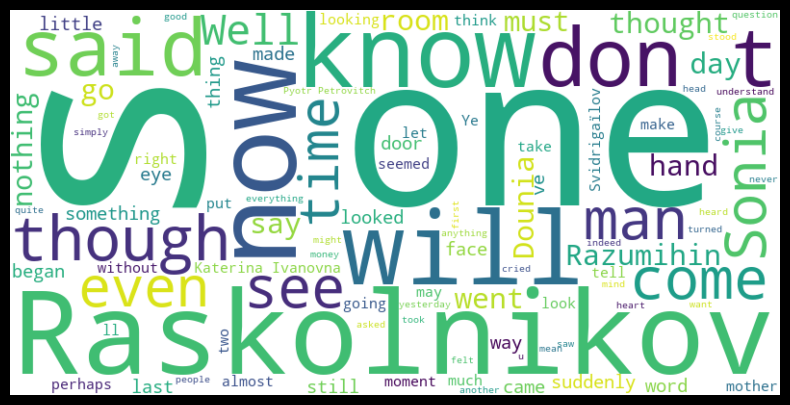

In [43]:
#!pip install wordcloud
from wordcloud import WordCloud
from matplotlib import pyplot as plt
wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(raw)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Named Entity Recognition (NER)

In [60]:
from nltk import word_tokenize, ne_chunk
from matplotlib import pyplot as plt

#Install tkinter first --> sudo apt-get install python3.7-tk
from nltk.draw.tree import draw_trees

import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker_tab')

# Input text
text = "Arash works at Amazon in Seattle, Texas"

# Tokenize and POS tag the text
tokens = word_tokenize(text)
tags = pos_tag(tokens)

# Perform named entity recognition
entities = ne_chunk(tags)
entities2 = ne_chunk(tags,binary=True)
# if we set the parameter binary=True then the named entities will be tagged as NE, or else the classfier will label such as PERSON, ORGANIZATION,

print(entities)
print(entities2)
#draw_trees(entities)
#plt.show()

ModuleNotFoundError: No module named 'tkinter'